In [1]:
import pandas as pd

url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
df = pd.read_csv(url)

df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [2]:
df.shape

(891, 12)

In [3]:
df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


In [4]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [5]:
df = df.drop(columns=["Cabin"])
df["Age"] = df["Age"].fillna(df["Age"].median())
df = df.dropna(subset=["Embarked"])
df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,0
SibSp,0
Parch,0
Ticket,0
Fare,0


In [6]:
df.groupby("Sex")["Survived"].mean().round(2)

,Survived
Sex,
female,0.74
male,0.19


In [7]:
df.groupby("Pclass")["Survived"].mean().round(2)

,Survived
Pclass,
1,0.63
2,0.47
3,0.24


In [8]:
df[["Age","Fare"]].corr()

,Age,Fare
Age,1.000000,0.093707
Fare,0.093707,1.000000


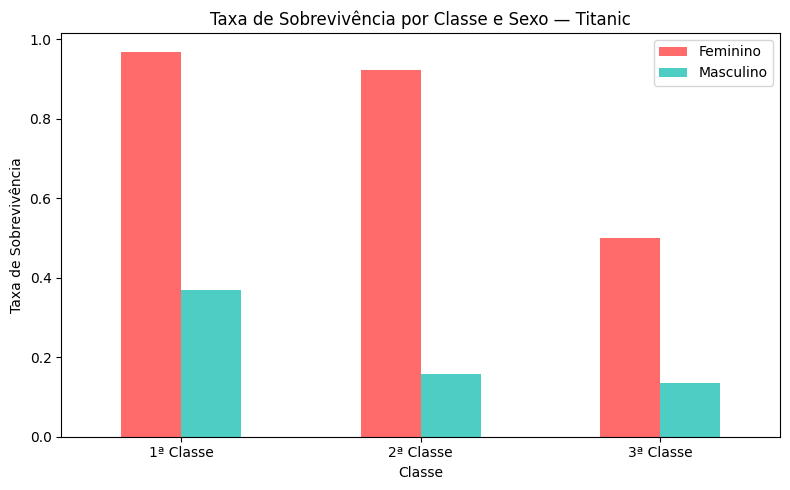

In [9]:
import matplotlib.pyplot as plt

# Gráfico de sobrevivência por classe e sexo
survival = df.groupby(["Pclass", "Sex"])["Survived"].mean().unstack()
survival.plot(kind="bar", figsize=(8,5), color=["#ff6b6b","#4ecdc4"])

plt.title("Taxa de Sobrevivência por Classe e Sexo — Titanic")
plt.xlabel("Classe")
plt.ylabel("Taxa de Sobrevivência")
plt.xticks([0,1,2], ["1ª Classe","2ª Classe","3ª Classe"], rotation=0)
plt.legend(["Feminino","Masculino"])
plt.tight_layout()
plt.show()